# How forecast horizon changes a consensus score
## Goal
Use the public **iPulse AI Historical Consensus Snapshots** to compare the same 373 assets at one-year and five-year forecast horizons. This tutorial covers loading a pinned release, checking its integrity, matching assets, comparing score signs, and inspecting forecast disagreement.

**Observed in Batch 6:** 115 of 373 assets (30.8%) have strictly opposite consensus-score signs between horizons. Median forecast-return dispersion is 9.33 percentage points at one year and 4.51 at five years. These describe stored forecasts, not observed investment outcomes.

Source: [Hugging Face dataset](https://huggingface.co/datasets/future-edge-group/ipulse-ai-historical-consensus-snapshots). Batch generated **5 July 2026**; scoring completed **8 July 2026**. Tutorial prepared **5 October 2026** by Future Edge Group FZE for iPulse AI, the Open Agentic Investment Research Platform. Founder: Russlan Ramdowar.

The asset cohort is dominated by equities (347 of 373 assets) and is not representative of the whole market. All comparisons below use this complete published cohort.

## Setup
Use Python 3.10 or newer. Install the small tutorial dependencies in your chosen environment:
```bash
pip install -r requirements-notebooks.txt
```
Or install `pandas`, `pyarrow`, `matplotlib`, `jupyter`, and `ipykernel` directly. No account, token, or production access is needed. The notebook fetches one public Parquet file and verifies its checksum before using it.

### Key assumptions
One row represents one asset and one horizon in a single snapshot. Pairing uses the released `asset_symbol`, which is sufficient within this fixed snapshot; it is not a permanent identity system for joining future releases. Score sign is a property of the combined consensus metric, not the sign of expected return or a buy/sell recommendation. Zero scores are kept as a separate state. Median absolute deviation (MAD) describes dispersion among forecasts; it is not an error estimate or confidence interval.

In [1]:
import hashlib
import io
import inspect
from urllib.request import urlopen
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

DATASET_ID = "future-edge-group/ipulse-ai-historical-consensus-snapshots"
REVISION = "9ef3156174da08f4233abefddc7b5a9ba6382483"
SNAPSHOT_ID = "ipulse-consensus-batch6-2026-07-05-v2.5"
EXPECTED_SHA256 = "7361482200e068969ae539ae78794441f62cc32c047494dda6ffb7aaed3db9e9"
SOURCE_URL = f"https://huggingface.co/datasets/{DATASET_ID}/resolve/{REVISION}/data/snapshots/2026-07-05.parquet"
plt.rcParams.update({"figure.figsize": (9, 6), "font.size": 12,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "axes.labelcolor": "#222222", "text.color": "#222222"})

## Steps
### 1. Load the exact published file
Pinning the Hub revision and checking SHA-256 prevents a later repository update from silently changing this tutorial's input.

In [2]:
with urlopen(SOURCE_URL, timeout=60) as response:
    parquet_bytes = response.read()
assert hashlib.sha256(parquet_bytes).hexdigest() == EXPECTED_SHA256
forecasts = pd.read_parquet(io.BytesIO(parquet_bytes))
assert len(forecasts) == 746
assert forecasts.asset_symbol.nunique() == 373
assert forecasts.snapshot_id.eq(SNAPSHOT_ID).all()
assert set(forecasts.forecast_horizon) == {"1y", "5y"}
assert not forecasts.duplicated(["snapshot_id", "asset_symbol", "forecast_horizon"]).any()
assert forecasts.groupby("asset_symbol").forecast_horizon.nunique().eq(2).all()
assert forecasts.source_algorithm_version.eq("v2.5").all()
assert forecasts.public_methodology_version.eq("v7.4").all()
assert forecasts.dataset_schema_version.eq("1.0.0").all()
display(Markdown(f"Verified **{len(forecasts):,} rows**, **{forecasts.asset_symbol.nunique():,} assets**, and the published SHA-256."))

Verified **746 rows**, **373 assets**, and the published SHA-256.

### 2. Match both horizons for every asset
Create a one-to-one join and validate that it preserves all 373 assets. This avoids comparing two differently selected populations.

In [3]:
one_year = forecasts.loc[forecasts.forecast_horizon.eq("1y")].copy()
five_year = forecasts.loc[forecasts.forecast_horizon.eq("5y")].copy()
paired = one_year.merge(five_year, on=["snapshot_id", "asset_symbol"],
                        suffixes=("_1y", "_5y"), validate="one_to_one", how="outer",
                        indicator=True)
assert len(paired) == 373 and paired._merge.eq("both").all()
assert paired.asset_category_1y.eq(paired.asset_category_5y).all()
assert paired[["ipulse_consensus_score_1y", "ipulse_consensus_score_5y"]].notna().all().all()
paired["opposite_score_sign"] = paired.ipulse_consensus_score_1y.mul(paired.ipulse_consensus_score_5y).lt(0)
paired["score_change"] = paired.ipulse_consensus_score_5y - paired.ipulse_consensus_score_1y
opposite_count = int(paired.opposite_score_sign.sum())
assert opposite_count == sum((row.ipulse_consensus_score_1y < 0 < row.ipulse_consensus_score_5y)
                            or (row.ipulse_consensus_score_5y < 0 < row.ipulse_consensus_score_1y)
                            for row in paired.itertuples())
display(Markdown(f"**{opposite_count}/{len(paired)} assets ({opposite_count/len(paired):.1%})** have strictly opposite score signs. Zero is excluded from that numerator, but retained in the cohort."))

**115/373 assets (30.8%)** have strictly opposite score signs. Zero is excluded from that numerator, but retained in the cohort.

### 3. Compare the scores
Each point is one asset. The dashed diagonal indicates equal scores at both horizons, while the solid zero lines separate score signs. A five-year score is not a future observation of the one-year score.

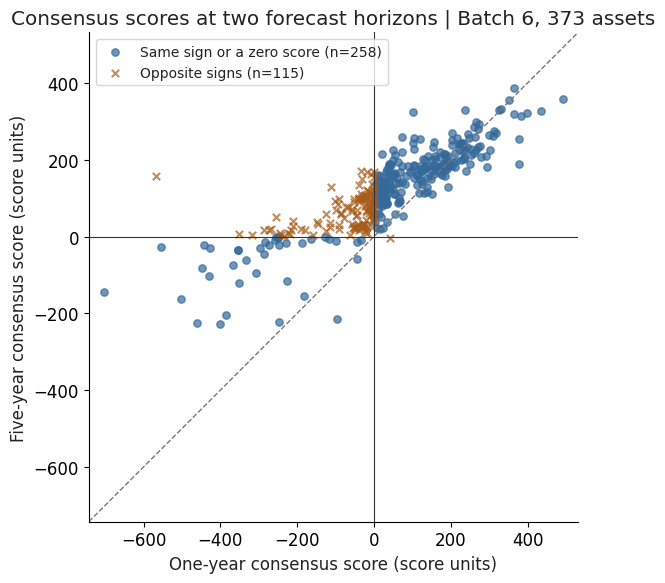

In [4]:
fig, ax = plt.subplots()
for opposite, label, marker, color in [
    (False, "Same sign or a zero score", "o", "#34699A"),
    (True, "Opposite signs", "x", "#A75B18")]:
    group = paired.loc[paired.opposite_score_sign.eq(opposite)]
    ax.scatter(group.ipulse_consensus_score_1y, group.ipulse_consensus_score_5y,
               label=f"{label} (n={len(group)})", marker=marker, color=color,
               alpha=0.7, s=28)
score_min = min(paired.ipulse_consensus_score_1y.min(), paired.ipulse_consensus_score_5y.min()) - 40
score_max = max(paired.ipulse_consensus_score_1y.max(), paired.ipulse_consensus_score_5y.max()) + 40
ax.plot([score_min, score_max], [score_min, score_max], linestyle="--", color="#777777", linewidth=1)
ax.axhline(0, color="#333333", linewidth=0.8)
ax.axvline(0, color="#333333", linewidth=0.8)
ax.set(xlim=(score_min, score_max), ylim=(score_min, score_max),
       xlabel="One-year consensus score (score units)", ylabel="Five-year consensus score (score units)",
       title="Consensus scores at two forecast horizons | Batch 6, 373 assets")
ax.set_aspect("equal", adjustable="box")
ax.legend(loc="upper left", fontsize=10)
fig.tight_layout()
plt.show()

Inspect the complete sign-transition table rather than only selected examples. Rows are the one-year score sign; columns are the five-year score sign.

In [5]:
sign_labels = {-1: "Negative", 0: "Zero", 1: "Positive"}
sign_1y = np.sign(paired.ipulse_consensus_score_1y).map(sign_labels)
sign_5y = np.sign(paired.ipulse_consensus_score_5y).map(sign_labels)
transitions = pd.crosstab(sign_1y, sign_5y).reindex(
    index=["Negative", "Zero", "Positive"], columns=["Negative", "Zero", "Positive"], fill_value=0)
transitions.index.name = "One-year score sign"
transitions.columns.name = "Five-year score sign"
assert transitions.to_numpy().sum() == 373
assert transitions.loc["Negative", "Positive"] + transitions.loc["Positive", "Negative"] == opposite_count
display(transitions)

Five-year score sign,Negative,Zero,Positive
One-year score sign,,,
Negative,36,2,114
Zero,0,0,1
Positive,1,0,219


### 4. Inspect forecast disagreement
The boxes below summarize forecast-return MAD across assets. Each horizon contains the same 373 assets. Whiskers follow the conventional 1.5-times-IQR rule; dots outside them are retained. This is a distribution of forecast disagreement, not a confidence interval for returns.

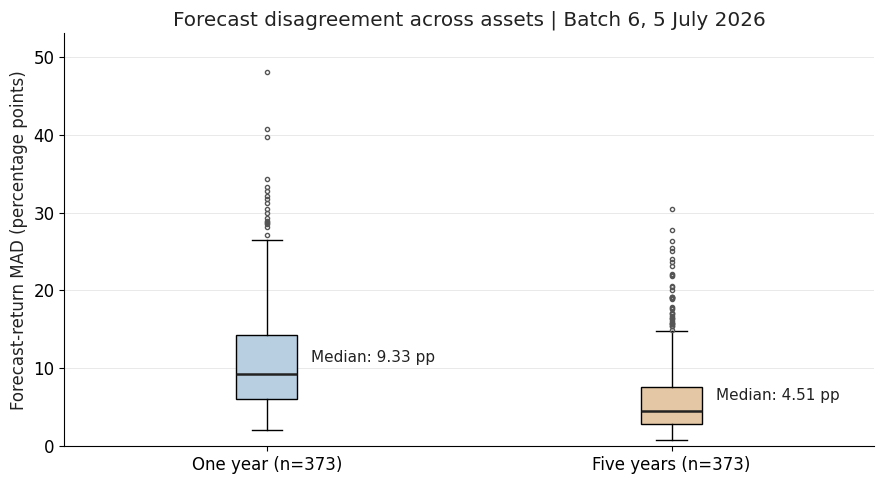

,assets,median_return_mad_pp,median_direction_agreement,median_direction_consistency
forecast_horizon,,,,
1y,373,9.33,0.8333,0.5886
5y,373,4.51,0.9167,0.7753


In [6]:
assert forecasts.forecast_return_mad_pct.notna().all()
assert forecasts.forecast_return_mad_pct.ge(0).all()
fig, ax = plt.subplots(figsize=(9, 5))
values = [forecasts.loc[forecasts.forecast_horizon.eq(h), "forecast_return_mad_pct"] for h in ["1y", "5y"]]
label_argument = "tick_labels" if "tick_labels" in inspect.signature(ax.boxplot).parameters else "labels"
boxes = ax.boxplot(values, **{label_argument: ["One year (n=373)", "Five years (n=373)"]}, patch_artist=True,
                   medianprops={"color": "#222222", "linewidth": 1.8},
                   flierprops={"marker": "o", "markersize": 3, "markerfacecolor": "none", "markeredgecolor": "#555555"})
for box, color in zip(boxes["boxes"], ["#B8CFE2", "#E4C8A5"]):
    box.set_facecolor(color)
for position, series in enumerate(values, start=1):
    ax.annotate(f"Median: {series.median():.2f} pp", (position, series.median()),
                xytext=(32, 8), textcoords="offset points", fontsize=11)
ax.set(ylabel="Forecast-return MAD (percentage points)", ylim=(0, 53),
       title="Forecast disagreement across assets | Batch 6, 5 July 2026")
ax.grid(axis="y", color="#E5E5E5", linewidth=0.6)
ax.set_axisbelow(True)
fig.tight_layout()
plt.show()

summary = forecasts.groupby("forecast_horizon").agg(
    assets=("asset_symbol", "nunique"), median_return_mad_pp=("forecast_return_mad_pct", "median"),
    median_direction_agreement=("direction_agreement", "median"),
    median_direction_consistency=("direction_consistency", "median"))
display(summary.round(4))

Five-year forecasts have lower median return dispersion and higher median direction agreement and path consistency in this snapshot. Higher agreement does not establish that the forecasts are correct. The medians summarize each horizon's full cohort; they do not imply that every asset improves or provide evidence of causation.

## Checks
Retain availability states when using financial-health scores. A missing score is not zero. Contributor voices, advisor identities, personas, and model families are different counts; multiple voices do not demonstrate multiple independent models.

In [7]:
coverage = forecasts.groupby(["financial_health_status", "forecast_horizon"]).size().unstack(fill_value=0)
assert coverage.to_numpy().sum() == 746
assert forecasts.loc[forecasts.financial_health_status.eq("NOT_APPLICABLE"), "financial_health_score"].isna().all()
display(coverage)
display(forecasts.groupby("forecast_horizon")[["voice_count", "advisor_count", "persona_count", "model_count"]].agg(["min", "max"]))

forecast_horizon,1y,5y
financial_health_status,,
AVAILABLE,330,330
INSUFFICIENT_DATA,2,2
NOT_APPLICABLE,26,26
PARTIAL,15,15


voice_count     advisor_count     persona_count      \
                         min max           min max           min max   
forecast_horizon                                                       
1y                        11  12             7   8             7   8   
5y                        11  12             7   8             7   8   

                 model_count      
                         min max  
forecast_horizon                  
1y                         1   1  
5y                         1   1

## Next Steps
Try repeating the score-sign comparison within each asset category, retaining the category counts so tiny groups remain visible. Inspect expected return and consensus score separately: they have different definitions and can have different signs. Use the companion [Batch 5 advisor forecast panel](https://huggingface.co/datasets/future-edge-group/ipulse-ai-batch5-advisor-forecast-panel) for advisor-level research, while respecting its separate cohort and methodology; these releases are not interchangeable.

This tutorial contains no outcome evaluation, accuracy claim, or current market recommendation. It is a reproducible example of examining historical model outputs. See the [metric dictionary](https://huggingface.co/datasets/future-edge-group/ipulse-ai-historical-consensus-snapshots/blob/9ef3156174da08f4233abefddc7b5a9ba6382483/schema/data-dictionary.md) and [methodology](https://huggingface.co/datasets/future-edge-group/ipulse-ai-historical-consensus-snapshots/blob/9ef3156174da08f4233abefddc7b5a9ba6382483/methodology/consensus-snapshot-methodology.md).

### Attribution
Future Edge Group FZE. *iPulse AI Historical Consensus Snapshots*, Batch 6 dated 2026-07-05, schema 1.0.0. Input SHA-256: `7361482200e068969ae539ae78794441f62cc32c047494dda6ffb7aaed3db9e9`. Dataset and tutorial: CC BY 4.0.